In [3]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mango-cat/ECS171-Project/main/malicious_phish.csv'
df = pd.read_csv(url)

print(df.shape)
df.head()

(651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [4]:
# Binary target banao: benign = 0, baaki sab (phishing/malware/defacement) = 1 (malicious)
df['label'] = df['type'].apply(lambda x: 0 if x == 'benign' else 1)

print(df['label'].value_counts())

# Dataset bara hai, isliye 50,000 rows ka balanced sample lete hain (speed ke liye)
benign_sample = df[df['label'] == 0].sample(n=25000, random_state=42)
malicious_sample = df[df['label'] == 1].sample(n=25000, random_state=42)
df_sample = pd.concat([benign_sample, malicious_sample]).reset_index(drop=True)

print(df_sample['label'].value_counts())
df_sample.head()

label
0    428103
1    223088
Name: count, dtype: int64
label
0    25000
1    25000
Name: count, dtype: int64


,url,type,label
0,montreal.louer.com/ahuntsic-rentals/houses-rent/,benign,0
1,comunidade.sol.pt/blogs/hytigin/default.aspx,benign,0
2,youtube.com/watch?v=PUDOlyCpHwo,benign,0
3,uiowa.edu/~acadtech/phonetics/,benign,0
4,flixster.com/actor/steve-mcqueen,benign,0


In [5]:
import re

def extract_features(url):
    features = {}
    features['url_length'] = len(url)
    features['num_dots'] = url.count('.')
    features['num_hyphens'] = url.count('-')
    features['num_at'] = url.count('@')
    features['num_question'] = url.count('?')
    features['num_equal'] = url.count('=')
    features['num_underscore'] = url.count('_')
    features['num_slash'] = url.count('/')
    features['num_digits'] = sum(c.isdigit() for c in url)
    features['has_ip'] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    features['has_https'] = 1 if 'https' in url else 0
    features['has_http'] = 1 if 'http://' in url else 0
    return features

# Har URL par ye function apply karo
feature_list = df_sample['url'].apply(extract_features)
features_df = pd.DataFrame(feature_list.tolist())

# Original data ke sath jodo
final_df = pd.concat([df_sample[['url', 'label']].reset_index(drop=True), features_df], axis=1)
final_df.head()

,url,label,url_length,num_dots,num_hyphens,num_at,num_question,num_equal,num_underscore,num_slash,num_digits,has_ip,has_https,has_http
0,montreal.louer.com/ahuntsic-rentals/houses-rent/,0,48,2,2,0,0,0,0,3,0,0,0,0
1,comunidade.sol.pt/blogs/hytigin/default.aspx,0,44,3,0,0,0,0,0,3,0,0,0,0
2,youtube.com/watch?v=PUDOlyCpHwo,0,31,1,0,0,1,1,0,1,0,0,0,0
3,uiowa.edu/~acadtech/phonetics/,0,30,1,0,0,0,0,0,3,0,0,0,0
4,flixster.com/actor/steve-mcqueen,0,32,1,1,0,0,0,0,2,0,0,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features aur target alag karo
feature_cols = ['url_length', 'num_dots', 'num_hyphens', 'num_at', 'num_question',
                 'num_equal', 'num_underscore', 'num_slash', 'num_digits',
                 'has_ip', 'has_https', 'has_http']
X = final_df[feature_cols]
y = final_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.8358   0.904658  0.749096  0.819560
1        Decision Tree    0.9184   0.923312  0.911812  0.917526
2        Random Forest    0.9303   0.934619  0.924669  0.929617


In [7]:
print(results_df)

# Best model dhoondo (F1-score ke basis par, kyunki phishing detection mein
# false negatives (phishing ko safe samajhna) zyada risky hote hain)
best_model_name = results_df.loc[results_df['F1'].idxmax(), 'Model']
print(f"\nBest Model: {best_model_name}")

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.8358   0.904658  0.749096  0.819560
1        Decision Tree    0.9184   0.923312  0.911812  0.917526
2        Random Forest    0.9303   0.934619  0.924669  0.929617

Best Model: Random Forest


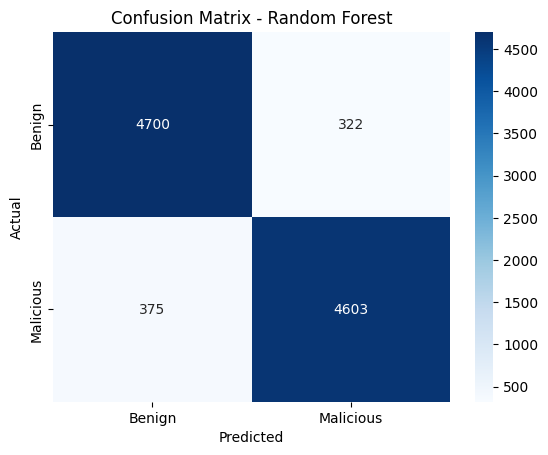

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = models[best_model_name]
pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malicious'],
            yticklabels=['Benign','Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [9]:
import re
from urllib.parse import urlparse

# Common shortening services (phishers inhe use karte hain URL chupane ke liye)
shortening_services = ['bit.ly', 'goo.gl', 'tinyurl', 't.co', 'ow.ly', 'is.gd', 'buff.ly']

# Suspicious keywords jo phishing URLs mein common hote hain
suspicious_keywords = ['login', 'verify', 'secure', 'account', 'bank', 'update',
                        'confirm', 'signin', 'password', 'security']

def extract_features_v2(url):
    features = {}
    features['url_length'] = len(url)
    features['num_dots'] = url.count('.')
    features['num_hyphens'] = url.count('-')
    features['num_at'] = url.count('@')
    features['num_question'] = url.count('?')
    features['num_equal'] = url.count('=')
    features['num_underscore'] = url.count('_')
    features['num_slash'] = url.count('/')
    features['num_digits'] = sum(c.isdigit() for c in url)
    features['has_ip'] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    features['has_https'] = 1 if 'https' in url else 0
    features['has_http'] = 1 if 'http://' in url else 0

    # --- Naye features ---

    # 1. Digit ratio (URL length ke against digits ka proportion)
    features['digit_ratio'] = features['num_digits'] / features['url_length'] if features['url_length'] > 0 else 0

    # 2. Suspicious keyword count
    url_lower = url.lower()
    features['suspicious_keyword_count'] = sum(1 for kw in suspicious_keywords if kw in url_lower)

    # 3. URL shortening service check
    features['is_shortened'] = 1 if any(s in url_lower for s in shortening_services) else 0

    # 4. Number of subdomains (domain ke dots count karo, path exclude karke)
    try:
        domain = urlparse(url if url.startswith('http') else 'http://' + url).netloc
        features['num_subdomains'] = domain.count('.')
    except:
        features['num_subdomains'] = 0

    # 5. Log of URL length (bahut lambe URLs ka effect normalize karta hai)
    import numpy as np
    features['url_length_log'] = np.log1p(features['url_length'])

    return features

# Re-apply on the same sample
feature_list_v2 = df_sample['url'].apply(extract_features_v2)
features_df_v2 = pd.DataFrame(feature_list_v2.tolist())
final_df_v2 = pd.concat([df_sample[['url', 'label']].reset_index(drop=True), features_df_v2], axis=1)
final_df_v2.head()

,url,label,url_length,num_dots,num_hyphens,num_at,num_question,num_equal,num_underscore,num_slash,num_digits,has_ip,has_https,has_http,digit_ratio,suspicious_keyword_count,is_shortened,num_subdomains,url_length_log
0,montreal.louer.com/ahuntsic-rentals/houses-rent/,0,48,2,2,0,0,0,0,3,0,0,0,0,0.0,0,0,2,3.891820
1,comunidade.sol.pt/blogs/hytigin/default.aspx,0,44,3,0,0,0,0,0,3,0,0,0,0,0.0,0,0,2,3.806662
2,youtube.com/watch?v=PUDOlyCpHwo,0,31,1,0,0,1,1,0,1,0,0,0,0,0.0,0,0,1,3.465736
3,uiowa.edu/~acadtech/phonetics/,0,30,1,0,0,0,0,0,3,0,0,0,0,0.0,0,0,1,3.433987
4,flixster.com/actor/steve-mcqueen,0,32,1,1,0,0,0,0,2,0,0,0,0,0.0,0,0,1,3.496508


In [10]:
feature_cols_v2 = ['url_length', 'num_dots', 'num_hyphens', 'num_at', 'num_question',
                    'num_equal', 'num_underscore', 'num_slash', 'num_digits',
                    'has_ip', 'has_https', 'has_http',
                    'digit_ratio', 'suspicious_keyword_count', 'is_shortened',
                    'num_subdomains', 'url_length_log']

X = final_df_v2[feature_cols_v2]
y = final_df_v2['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_final = RandomForestClassifier(random_state=42, n_estimators=200)
rf_final.fit(X_train_scaled, y_train)
pred = rf_final.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

# Feature importance dekho — ye README aur video mein dikhane ke liye great hai
importances = pd.Series(rf_final.feature_importances_, index=feature_cols_v2).sort_values(ascending=False)
print(importances)

Accuracy: 0.9412
Precision: 0.9450527169505272
Recall: 0.9363198071514665
F1: 0.9406659939455095
has_http                    0.244704
num_slash                   0.181623
num_subdomains              0.100520
num_dots                    0.093937
url_length_log              0.067718
url_length                  0.066636
has_https                   0.050247
digit_ratio                 0.039349
num_hyphens                 0.037761
num_digits                  0.032270
num_equal                   0.029953
num_underscore              0.023722
suspicious_keyword_count    0.010015
num_question                0.009990
is_shortened                0.006574
has_ip                      0.004451
num_at                      0.000530
dtype: float64


In [11]:
import joblib

# Model aur scaler dono save karo
joblib.dump(rf_final, 'phishing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Feature column order bhi save karo (Streamlit app mein zaroori hoga
# taake input features training ke exact same order mein bane)
joblib.dump(feature_cols_v2, 'feature_columns.pkl')

print("Saved: phishing_model.pkl, scaler.pkl, feature_columns.pkl")

Saved: phishing_model.pkl, scaler.pkl, feature_columns.pkl


In [12]:
from google.colab import files
files.download('phishing_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>